In [12]:
import numpy as np
from math import atan2, sqrt, pi
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

In [13]:
class GPA:
    def __init__(self, matrix):
        """
        Gradient Pattern Analysis (GPA) implementation.

        This class implements the Gradient Pattern Analysis (GPA) method for
        two-dimensional images. Given an input image, it computes the gradient
        field, removes radially symmetric gradient vectors with respect to a
        reference center, and evaluates the four GPA moments (G1, G2, G3, and G4).

        Reference
        ---------
        Paper:
        <insert paper citation or DOI here>

        Example
        -------
        >>> gpa = GPA(image)
        >>> gpa.setPosition(cx, cy)
        >>> results = gpa.evaluate(
        ...     mtol=0.02,
        ...     ftol=0.03,
        ...     ptol=0.01
        ... )

        The analysis center is defined with ``setPosition(cx, cy)``, where
        ``(cx, cy)`` corresponds to the point from which radial symmetry is
        evaluated. By default, the geometric center of the image is used.

        The tolerance parameters control the removal of radially symmetric
        gradient vectors:

        - ``mtol`` : Magnitude tolerance. Maximum allowed difference between the
        magnitudes of two gradient vectors for them to be considered symmetric.
        - ``ftol`` : Angular (phase) tolerance. Maximum allowed difference
        between the orientations (phases) of two gradient vectors.
        - ``ptol`` : Position tolerance. Maximum allowed deviation from perfect
        radial symmetry between two vectors.

        The ``evaluate()`` method returns a dictionary containing the requested
        GPA moments, for example:

        >>> {
        ...     "G1": 0.81,
        ...     "G2": 0.34,
        ...     "G3": 1.25,
        ...     "G4": 4.12
        ... }

        Parameters
        ----------
        matrix : numpy.ndarray
            Two-dimensional input image :math:`I(x, y)`. The input must be a
            2D NumPy array.
        """

        if not isinstance(matrix, np.ndarray):
            raise TypeError(
                f"'matrix' must be a numpy.ndarray, got {type(matrix).__name__}."
            )

        # Check whether it is a two-dimensional matrix
        if matrix.ndim != 2:
            raise ValueError(
                f"'matrix' must be a 2D matrix, got an array with {matrix.ndim} dimensions."
            )
        
        # Convert only the data type without creating a copy if unnecessary
        self.matrix = matrix.astype(np.float32, copy=False)


        # Input image converted to float32
        self.matrix = np.asarray(matrix, dtype=np.float32)

        # Coordinates of the image center
        self.cx = (len(self.matrix) - 1) / 2
        self.cy = (len(self.matrix[0]) - 1) / 2

        # Image dimensions
        self.rows, self.cols = self.matrix.shape


        # Gradient field components:
        #
        # ∇I = (Gx, Gy)
        #
        self.gradient_dx = None
        self.gradient_dy = None


        # Gradient field after removing
        # radially symmetric vectors
        self.gradient_asymmetric_dx = None
        self.gradient_asymmetric_dy = None


        # Gradient properties:
        #
        # phases -> orientation:
        # θ = atan2(Gy, Gx)
        #
        # mods -> magnitude:
        # |∇I| = sqrt(Gx² + Gy²)
        #
        self.phases = None
        self.mods = None


        # Coordinates of the removed points and
        # the remaining asymmetric points
        self.removedP = np.empty((0, 2), dtype=np.int32)
        self.nremovedP = np.empty((0, 2), dtype=np.int32)


        # Total number of gradient vectors and
        # remaining asymmetric vectors
        self.totalVet = self.rows * self.cols
        self.totalAssimetric = self.rows * self.cols


        # Measure of gradient orientation diversity
        self.phaseDiversity = 0.0

        # Maximum gradient magnitude found in the image
        self.maxGrad = 0.0

    def setPosition(self, cx, cy):
        self.cx = float(cx)
        self.cy = float(cy)


    
    def evaluate(self, mtol, ftol, ptol, mask=None, plot=False,
                moments=["G1", "G2", "G3", "G4"]):
        """
        Perform Gradient Pattern Analysis (GPA) and compute the selected
        gradient moments.

        The analysis consists of the following steps:

        1. Compute the image gradient field:

            ∇I(x, y) = (Gx, Gy)

        2. Group gradient vectors according to the radial distance of their
        positions from the analysis center.

        3. Identify and remove radially symmetric gradient-vector pairs,
        preserving only the asymmetric contributions.

        4. Compute the selected GPA moments:

            G1, G2, G3, and G4.

        Parameters
        ----------
        mtol : float
            Magnitude tolerance used to compare the magnitudes of symmetric
            gradient vectors.
        ftol : float
            Angular tolerance used to compare the orientations of opposite
            gradient vectors.
        ptol : float
            Positional tolerance used when identifying radially symmetric
            vector pairs.
        mask : numpy.ndarray, optional
            Binary mask defining the valid image region. If ``None``, the
            entire image is considered.
        plot : bool, default=False
            If ``True``, display the gradient field.
        moments : list of str, optional
            GPA moments to compute. Valid options are ``"G1"``, ``"G2"``,
            ``"G3"``, and ``"G4"``.

        Returns
        -------
        dict
            Dictionary containing the requested GPA moments.
        """
        if mask is None:
            mask = np.ones_like(self.matrix, dtype=np.float32)

        # Compute the image gradient field, as well as the
        # corresponding magnitudes and orientations.
        self._setGradients(plot)


        # Update the image dimensions
        self.cols = len(self.matrix[0])
        self.rows = len(self.matrix)


        # Compute the radial distance map:
        #
        # r = sqrt((x - cx)² + (y - cy)²)
        #
        # Each pixel is assigned its integer radial distance
        # from the analysis center.
        radial_distance_map = np.array([
            [
                int(np.sqrt((x - self.cx)**2 + (y - self.cy)**2))
                for x in range(self.cols)
            ]
            for y in range(self.rows)
        ], dtype=np.int32)


        # Retrieve the unique radial distances present in the image
        unique_radii = np.unique(radial_distance_map).astype(np.int32)


        # Remove radially symmetric gradient vectors,
        # producing the asymmetric gradient field.
        self._update_asymmetric_mat(
            mask,
            unique_radii,
            radial_distance_map,
            mtol,
            ftol,
            ptol
        )


        # Allow a single GPA moment to be specified as a string
        if isinstance(moments, str):
            moments = [moments]

        elif isinstance(moments, tuple):
            moments = list(moments)


        # Map each GPA moment name to its corresponding function
        available_moments = {
            "G1": self._G1,
            "G2": self._G2,
            "G3": self._G3,
            "G4": self._G4
        }


        results = {}

        # Compute the requested GPA moments
        for moment in moments:

            if moment not in available_moments:
                raise ValueError(
                    f"Invalid GPA moment '{moment}'. "
                    f"Available options are: {list(available_moments.keys())}"
                )

            results[moment] = available_moments[moment]()


        return results


        
    def _setGradients(self, plot):
        """
        Compute the image gradient field and its associated properties.

        For an image I(x, y), the gradient is defined as:

            ∇I(x, y) = (Gx, Gy)

        where:

            Gx = ∂I/∂x

        is the intensity variation along the horizontal direction, and

            Gy = ∂I/∂y

        is the intensity variation along the vertical direction.

        The gradient magnitude is computed as:

            |∇I| = sqrt(Gx² + Gy²)

        which measures the strength of the local intensity variation.

        The gradient orientation is given by:

            θ = atan2(Gy, Gx)

        representing the angle of the gradient vector with respect to the
        x-axis.

        These quantities are subsequently used by the GPA algorithm to
        identify asymmetric structures through comparisons of gradient
        vector magnitudes and orientations.
        """

        # Compute the horizontal (gx) and vertical (gy)
        # gradients of the input image.
        #
        # gx = ∂I/∂x
        # gy = ∂I/∂y
        gy, gx = self.gradient(self.matrix)

        # Store the original gradient components.
        # These arrays remain unchanged throughout the analysis.
        self.gradient_dx = gx.copy()
        self.gradient_dy = gy.copy()

        # Create copies of the gradient components that will
        # be modified during the symmetry-removal procedure.
        self.gradient_asymmetric_dx = gx.copy()
        self.gradient_asymmetric_dy = gy.copy()

        # Compute the gradient magnitude:
        #
        # |∇I| = sqrt(Gx² + Gy²)
        self.mods = np.sqrt(gx**2 + gy**2)

        # Store the maximum gradient magnitude.
        # This value is used later for normalization:
        #
        # |∇I| / max(|∇I|)
        self.maxGrad = self.mods.max()

        # Compute the gradient orientation:
        #
        # θ = atan2(Gy, Gx)
        #
        # The result is initially in the interval [-π, π].
        angle = np.arctan2(gy, gx)

        # Convert negative angles to the interval [0, 2π].
        self.phases = np.where(
            angle >= 0,
            angle,
            angle + 2 * np.pi
        ).astype(np.float32)

        if plot:
            self._plot_gradient_field(gx, gy)



    def gradient(self, matrix):
        """
        Compute the spatial gradient of a two-dimensional image using
        finite differences.

        For an image I(x, y), the gradient is defined as:

            ∇I(x, y) = (Gx, Gy)

        where:

            Gx = ∂I/∂x
            Gy = ∂I/∂y

        Central differences are used for interior pixels:

            Gx = [I(x+1, y) - I(x-1, y)] / 2
            Gy = [I(x, y+1) - I(x, y-1)] / 2

        Forward and backward differences are used at the image boundaries.

        Parameters
        ----------
        matrix : numpy.ndarray
            Two-dimensional input image.

        Returns
        -------
        tuple of numpy.ndarray
            A tuple ``(dy, dx)`` containing the vertical and horizontal
            gradient components, respectively.
        """

        # Image dimensions
        h, w = matrix.shape

        # Allocate the gradient component arrays
        dx = np.zeros((h, w), dtype=np.float32)
        dy = np.zeros((h, w), dtype=np.float32)

        # Compute the gradient at each pixel
        for j in range(h):
            for i in range(w):

                # Vertical gradient (∂I/∂y)
                #
                # Use central differences for interior pixels.
                if 0 < j < h - 1:
                    dy[j, i] = (matrix[j + 1, i] - matrix[j - 1, i]) / 2.0

                # Use forward differences along the top boundary.
                elif j < h - 1:
                    dy[j, i] = matrix[j + 1, i] - matrix[j, i]

                # Use backward differences along the bottom boundary.
                elif j > 0:
                    dy[j, i] = matrix[j, i] - matrix[j - 1, i]

                # Horizontal gradient (∂I/∂x)
                #
                # Use central differences for interior pixels.
                if 0 < i < w - 1:
                    dx[j, i] = (matrix[j, i + 1] - matrix[j, i - 1]) / 2.0

                # Use forward differences along the left boundary.
                elif i < w - 1:
                    dx[j, i] = matrix[j, i + 1] - matrix[j, i]

                # Use backward differences along the right boundary.
                elif i > 0:
                    dx[j, i] = matrix[j, i] - matrix[j, i - 1]

        return dy, dx

    

    def _plot_gradient_field(self, gx, gy, fixed_length=True):
        """
        Display the image gradient field as a vector plot.

        Each arrow represents a gradient vector:

            ∇I = (Gx, Gy)

        When ``fixed_length=True``, all arrows are normalized to the same
        length so that only the gradient orientations are visualized.

        When ``fixed_length=False``, the arrow lengths are proportional to
        the gradient magnitudes:

            |∇I| = sqrt(Gx² + Gy²)

        Parameters
        ----------
        gx : numpy.ndarray
            Horizontal gradient component.
        gy : numpy.ndarray
            Vertical gradient component.
        fixed_length : bool, default=True
            If ``True``, normalize all gradient vectors to unit length for
            visualization. Otherwise, display vectors with their original
            magnitudes.
        """

        # Create a coordinate grid for the image
        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        # Normalize the vectors or preserve their original magnitudes
        if fixed_length:

            magnitude = np.sqrt(gx**2 + gy**2)

            # Avoid division by zero in regions with zero gradient
            magnitude[magnitude == 0] = 1

            scale = 0.8

            u = (gx / magnitude) * scale
            v = (gy / magnitude) * scale

        else:

            u = gx
            v = gy

        plt.figure(figsize=(8, 8))

        # Display the input image as the background
        plt.imshow(
            self.matrix,
            cmap="gray",
            origin="upper"
        )

        # Overlay the gradient vector field
        plt.quiver(
            x,
            y,
            u,
            v,
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1
        )

        plt.title("Gradient Field")
        plt.xlabel("x")
        plt.ylabel("y")

        # Match the image coordinate system
        plt.gca().invert_yaxis()

        plt.show()




    def _update_asymmetric_mat(self, mask, unique_radii,
                           radial_distance_map,
                           mtol, ftol, ptol):
        """
        Remove radially symmetric contributions from the gradient field.

        Starting from the gradient field

            ∇I(x, y) = (Gx, Gy),

        where the gradient magnitude is

            |∇I| = sqrt(Gx² + Gy²)

        and the gradient orientation is

            θ = atan2(Gy, Gx),

        the algorithm groups gradient vectors according to the radial
        distance of their positions from the analysis center.

        Two gradient vectors within the same radial group are considered
        radially symmetric if they simultaneously satisfy:

        1. Similar gradient magnitudes:

            ||∇I₁| - |∇I₂|| ≤ mtol · max(|∇I|)

        2. Approximately opposite orientations:

            |Δθ - π| ≤ ftol

        where

            Δθ

        is the angular difference between the two gradient vectors.

        When these conditions are satisfied, both vectors are removed by
        setting

            Gx = 0
            Gy = 0

        yielding the asymmetric gradient field

            ∇I_asym = (Gx_asym, Gy_asym),

        which contains only the gradient vectors associated with asymmetric
        image structures.

        Parameters
        ----------
        mask : numpy.ndarray
            Binary image mask. Pixels with a value of zero are ignored.

        unique_radii : numpy.ndarray
            Array containing the distinct radial distances.

        radial_distance_map : numpy.ndarray
            Integer-valued radial distance of every pixel from the analysis
            center.

        mtol : float
            Magnitude tolerance for comparing gradient vectors.

        ftol : float
            Angular tolerance for identifying opposite gradient vectors.

        ptol : float
            Radial distance tolerance used to group gradient vectors.
        """

        # Convert the arrays to the same data types used by the
        # original Cython implementation.
        mask = np.asarray(mask, dtype=np.float32)
        unique_radii = np.asarray(unique_radii, dtype=np.int32)
        radial_distance_map = np.asarray(radial_distance_map, dtype=np.int32)

        # Convert the tolerance values to float32.
        mtol = np.float32(mtol)
        ftol = np.float32(ftol)
        ptol = np.float32(ptol)

        removedP = []

        # Process each radial distance.
        # Gradient vectors belonging to the same radial group
        # may form symmetric pairs.
        for ind in range(0, len(unique_radii), 1):

            x2 = []
            y2 = []

            # Collect all pixels belonging to the current
            # radial distance.
            for py in range(self.rows):
                for px in range(self.cols):

                    if abs(radial_distance_map[py, px] - ind) <= abs(ptol):
                        x2.append(px)
                        y2.append(py)

            # Pixel coordinates within the current radial group.
            x = np.array(x2, dtype=np.int32)
            y = np.array(y2, dtype=np.int32)

            lx = len(x)

            # Compare every pair of gradient vectors in the
            # current radial group.
            for i in range(lx):

                px = x[i]
                py = y[i]

                # Remove gradient vectors whose magnitude is
                # below the specified threshold.
                if (self.mods[py, px] / self.maxGrad) <= mtol:
                    self.gradient_asymmetric_dx[py, px] = np.float32(0.0)
                    self.gradient_asymmetric_dy[py, px] = np.float32(0.0)

                # Ignore masked pixels.
                if mask[py, px] == 0:
                    continue

                # Compare the current vector with the remaining
                # vectors in the same radial group.
                for j in range(i + 1, lx):

                    px2 = x[j]
                    py2 = y[j]

                    if mask[py2, px2] == 0:
                        continue

                    # Check whether the gradient magnitudes are similar.
                    if abs(self.mods[py, px] - self.mods[py2, px2]) <= mtol * self.maxGrad:

                        # Check whether the gradient vectors have
                        # approximately opposite orientations.
                        if abs(
                            self._angleDifference(
                                self.phases[py, px],
                                self.phases[py2, px2]
                            ) - np.pi
                        ) <= ftol:

                            # Remove both vectors since they represent
                            # a radially symmetric contribution.
                            self.gradient_asymmetric_dx[py, px] = np.float32(0.0)
                            self.gradient_asymmetric_dy[py, px] = np.float32(0.0)

                            self.gradient_asymmetric_dx[py2, px2] = np.float32(0.0)
                            self.gradient_asymmetric_dy[py2, px2] = np.float32(0.0)

                            break

        # Preserve compatibility with the original Cython implementation.
        if len(removedP) > 0:
            self.removedP = np.array(removedP, dtype=np.int32)

        # Reset the vector counters.
        self.totalVet = 0
        self.totalAssimetric = 0

        nremovedP = []

        # Count the remaining asymmetric vectors.
        for j in range(self.rows):
            for i in range(self.cols):

                # Valid asymmetric gradient vector.
                if (
                    self.gradient_asymmetric_dy[j, i] != 0.0
                    and self.gradient_asymmetric_dx[j, i] != 0.0
                    and mask[j, i] != 0.0
                ):
                    nremovedP.append([j, i])
                    self.totalVet += 1

                # Gradient vector removed due to radial symmetry.
                elif mask[j, i] != 0.0:
                    removedP.append([j, i])
                    self.totalVet += 1
                    self.totalAssimetric += 1

        # Store the remaining asymmetric points.
        if len(nremovedP) > 0:
            self.nremovedP = np.array(nremovedP, dtype=np.int32)
    
    def _angleDifference(self, a1, a2):
      return min(abs(a1-a2), abs(abs(a1-a2)-2*np.pi))
    

    
    def _G1(self):
         
        return
    def _G3(self):
         
        return
    def _G4(self):
         
        return

    def _G2(self):
        """
        Compute the second Gradient Pattern Analysis (GPA) moment.

        The second GPA moment is defined as

            G2 = (V / VA) · (2 - D)

        where

            V  = number of remaining asymmetric gradient vectors,
            VA = total number of valid gradient vectors, and

            D = |Σvi| / Σ|vi|

        is the vectorial diversity (or alignment) measure. Values of
        ``D`` close to 1 indicate highly aligned gradient vectors,
        whereas smaller values indicate greater directional diversity.

        Returns
        -------
        float
            The second GPA moment (G2).
        """

        # Count the remaining asymmetric gradient vectors.
        if len(self.nremovedP) > 0:
            self.totalAssimetric = len(self.nremovedP[:, 0])
        else:
            self.totalAssimetric = 0

        # Compute the vectorial diversity:
        #
        # D = |Σvi| / Σ|vi|
        self.phaseDiversity = self._vectorialVariety()

        # Compute the second GPA moment:
        #
        # G2 = (V / VA) · (2 - D)
        G2 = (
            float(self.totalAssimetric) / float(self.totalVet)
        ) * (2.0 - self.phaseDiversity)

        return G2

    def _vectorialVariety(self):
        """
        Compute the vectorial diversity (alignment) measure.

        The quantity is defined as

            D = |Σvi| / Σ|vi|

        where

            vi = (Gx, Gy)

        is an asymmetric gradient vector.

        This measure quantifies the overall alignment of the asymmetric
        gradient vectors. Values close to 1 indicate that the vectors are
        predominantly aligned in the same direction, whereas values close
        to 0 indicate a more diverse or isotropic distribution of
        orientations.

        Returns
        -------
        float
            The vectorial diversity (alignment) measure.
        """

        sum_x = 0.0
        sum_y = 0.0
        sum_magnitude = 0.0

        # No asymmetric vectors are available.
        if self.totalAssimetric < 1:
            return 0.0

        # Sum the asymmetric gradient vectors.
        for i in range(self.totalAssimetric):

            row = self.nremovedP[i, 0]
            col = self.nremovedP[i, 1]

            # Gradient magnitude:
            #
            # |vi| = sqrt(Gx² + Gy²)
            magnitude = self.mods[row, col]

            sum_x += self.gradient_dx[row, col]
            sum_y += self.gradient_dy[row, col]

            # Sum of the vector magnitudes.
            sum_magnitude += magnitude

        if sum_magnitude <= 0.0:
            return 0.0

        # Compute the vectorial diversity:
        #
        # D = sqrt((ΣGx)² + (ΣGy)²) / Σ|vi|
        vectorial_diversity = (
            np.sqrt(sum_x**2 + sum_y**2) / sum_magnitude
        )

        return vectorial_diversity


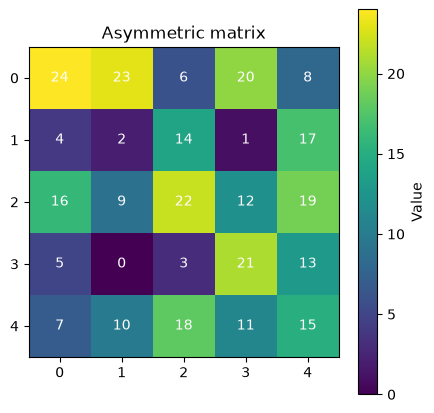

In [14]:
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)
    values = np.arange(n * n)
    rng.shuffle(values)
    return values.reshape((n, n))


# Example
asymmetric = create_asymmetric_matrix(5)

plt.figure(figsize=(5, 5))
plt.imshow(asymmetric, cmap="viridis", origin="upper")
plt.colorbar(label="Value")
plt.title("Asymmetric matrix")
plt.xticks(range(asymmetric.shape[1]))
plt.yticks(range(asymmetric.shape[0]))

# Write values inside each cell
for i in range(asymmetric.shape[0]):
    for j in range(asymmetric.shape[1]):
        plt.text(
            j, i, str(asymmetric[i, j]),
            ha="center",
            va="center",
            color="white",
            fontsize=10
        )

plt.show()

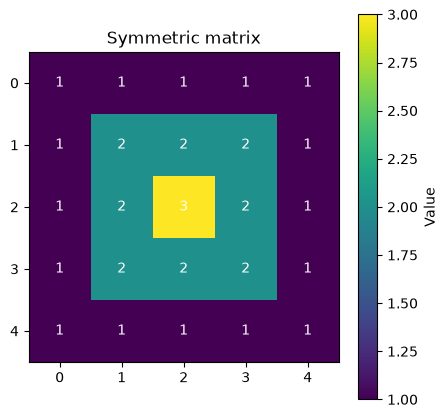

In [15]:
def create_symmetric_matrix(n):
    center = (n - 1) / 2
    matrix = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            distance = max(abs(i - center), abs(j - center))
            matrix[i, j] = int(center + 1 - distance)

    return matrix


symmetric = create_symmetric_matrix(5)

plt.figure(figsize=(5, 5))
plt.imshow(symmetric, cmap="viridis", origin="upper")
plt.colorbar(label="Value")
plt.title("Symmetric matrix")
plt.xticks(range(symmetric.shape[1]))
plt.yticks(range(symmetric.shape[0]))

# Write values inside each cell
for i in range(symmetric.shape[0]):
    for j in range(symmetric.shape[1]):
        plt.text(
            j, i, str(symmetric[i, j]),
            ha="center",
            va="center",
            color="white",
            fontsize=10
        )

plt.show()

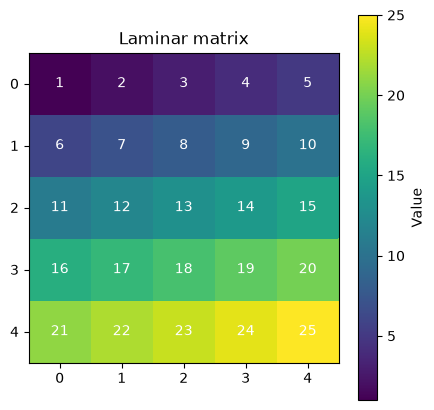

In [16]:
def create_laminar_matrix(n):
    """
    Creates an n x n matrix with increasing values row by row.
    """
    return np.arange(1, n * n + 1).reshape(n, n)


# Example
laminar = create_laminar_matrix(5)

plt.figure(figsize=(5, 5))
plt.imshow(laminar, cmap="viridis", origin="upper")
plt.colorbar(label="Value")
plt.title("Laminar matrix")
plt.xticks(range(laminar.shape[1]))
plt.yticks(range(laminar.shape[0]))

# Write values inside each cell
for i in range(laminar.shape[0]):
    for j in range(laminar.shape[1]):
        plt.text(
            j, i, str(laminar[i, j]),
            ha="center",
            va="center",
            color="white",
            fontsize=10
        )

plt.show()

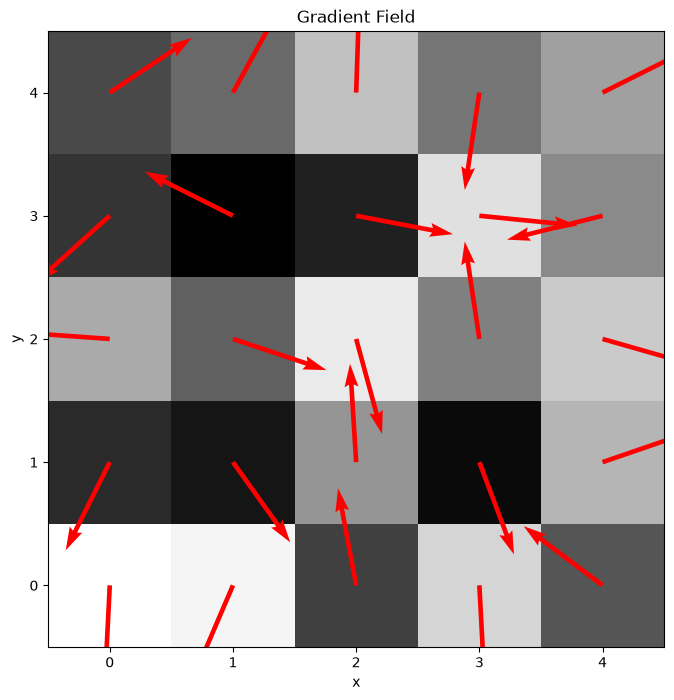

{'G2': np.float32(1.8534598)}

In [17]:
gpaObject = GPA(asymmetric)
gpaObject.setPosition(2, 2)
gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582, plot=True,moments="G2")

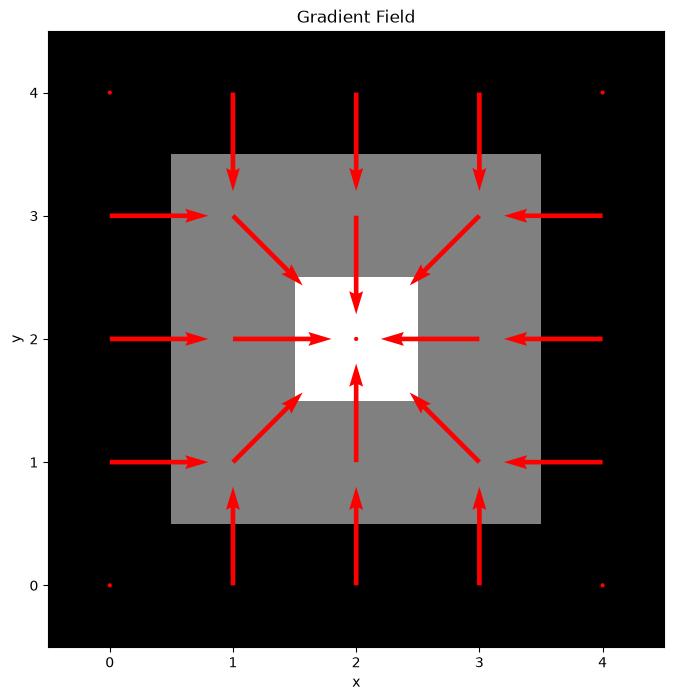

{'G2': 0.0}

In [18]:
gpaObject = GPA(symmetric)
gpaObject.setPosition((len(symmetric)-1)/2, (len(symmetric[0])-1)/2)

gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582, plot=True, moments=("G2"))

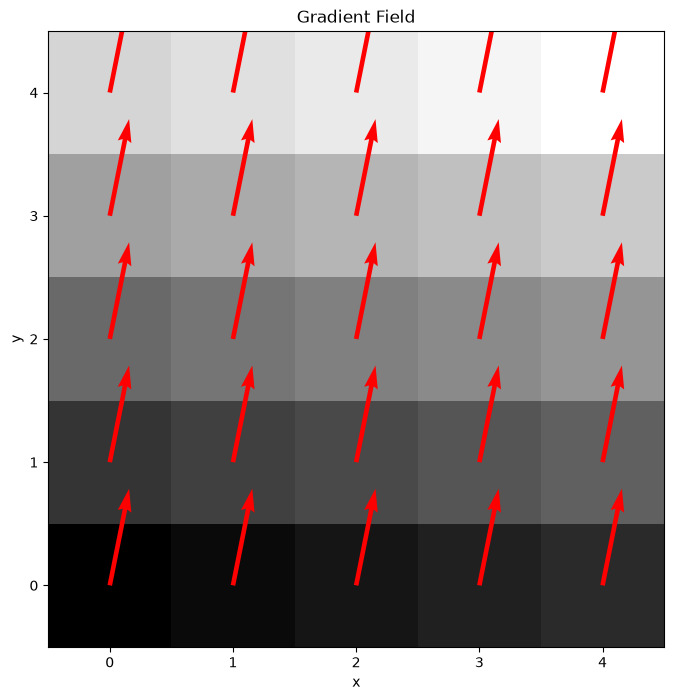

{'G2': np.float32(1.0000002)}

In [19]:
gpaObject = GPA(laminar)
gpaObject.setPosition(2, 2)
gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582, plot=True, moments=("G2"))